In [131]:
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine

In [132]:
# connect to local teslamate database
engine = create_engine("postgresql://localhost/teslamate_local")

# only load columns we need
query = """
SELECT date, latitude, longitude, speed
FROM positions
WHERE latitude IS NOT NULL
  AND longitude IS NOT NULL
  AND speed IS NOT NULL
"""

df = pd.read_sql(query, engine)

In [133]:
# convert date column
df["date"] = pd.to_datetime(df["date"])

# extract hour for time-based analysis
df["hour"] = df["date"].dt.hour

In [134]:
# isolate a representative segment of O-4
df_filtered = df[
    (df["latitude"] <= 40.985) &   # west limit
    (df["latitude"] >= 40.950) &   # east limit
    (df["longitude"] >= 29.195) &  # slightly padded
    (df["longitude"] <= 29.305)
].copy()

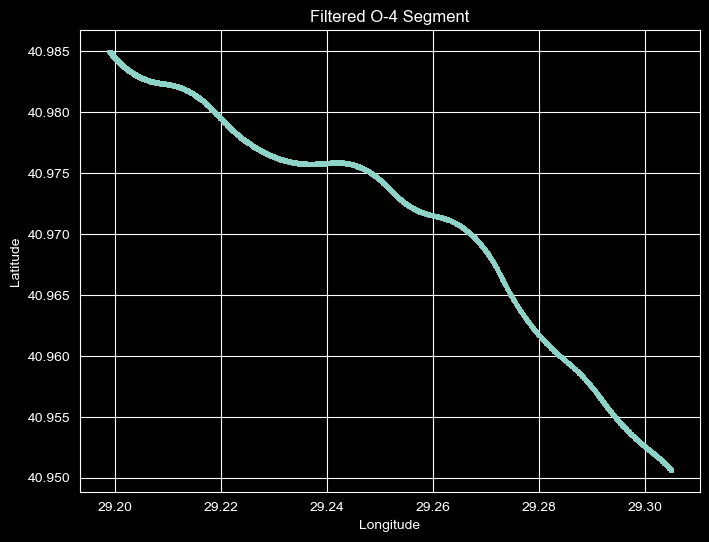

In [135]:
# basic map to verify filtering worked
plt.figure(figsize=(8,6))
plt.scatter(df_filtered["longitude"], df_filtered["latitude"], s=1)
plt.title("Filtered O-4 Segment")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

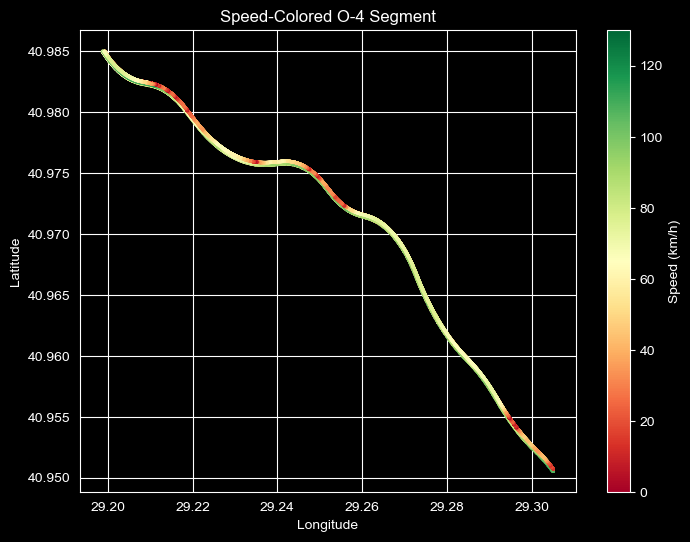

In [136]:
# main EDA visualization
plt.figure(figsize=(8,6))
plt.scatter(
    df_filtered["longitude"],
    df_filtered["latitude"],
    c=df_filtered["speed"],
    cmap="RdYlGn",
    s=2
)
plt.colorbar(label="Speed (km/h)")
plt.title("Speed-Colored O-4 Segment")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

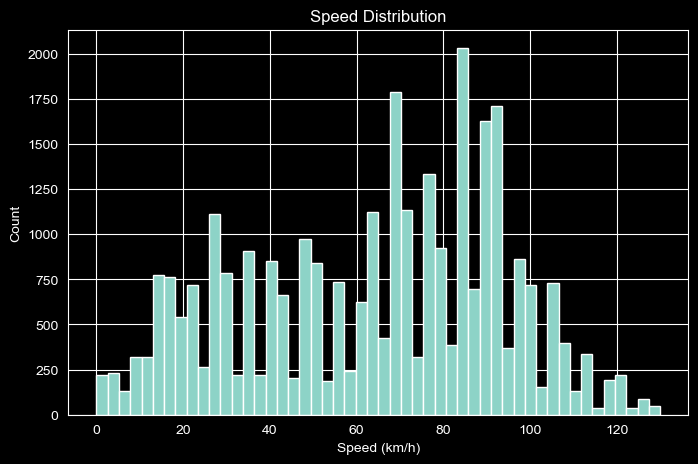

In [137]:
# simple distribution of speeds
plt.figure(figsize=(8,5))
df_filtered["speed"].hist(bins=50)
plt.title("Speed Distribution")
plt.xlabel("Speed (km/h)")
plt.ylabel("Count")
plt.show()

In [138]:
def assign_window(dt):
    minutes = dt.hour * 60 + dt.minute

    if 6*60 <= minutes < 10*60 + 30:
        return "Morning Peak"
    elif 10*60 + 30 <= minutes < 14*60 + 30:
        return "Midday"
    elif 15*60 <= minutes < 20*60:
        return "Evening Peak"
    else:
        return None

df_filtered["time_window"] = df_filtered["date"].apply(assign_window)

df_time = df_filtered[df_filtered["time_window"].notna()].copy()

In [139]:
# direction approximation based on commute pattern
def assign_direction(hour):
    if hour < 15:
        return "Eastbound"
    else:
        return "Westbound"

df_filtered["direction"] = df_filtered["hour"].apply(assign_direction)

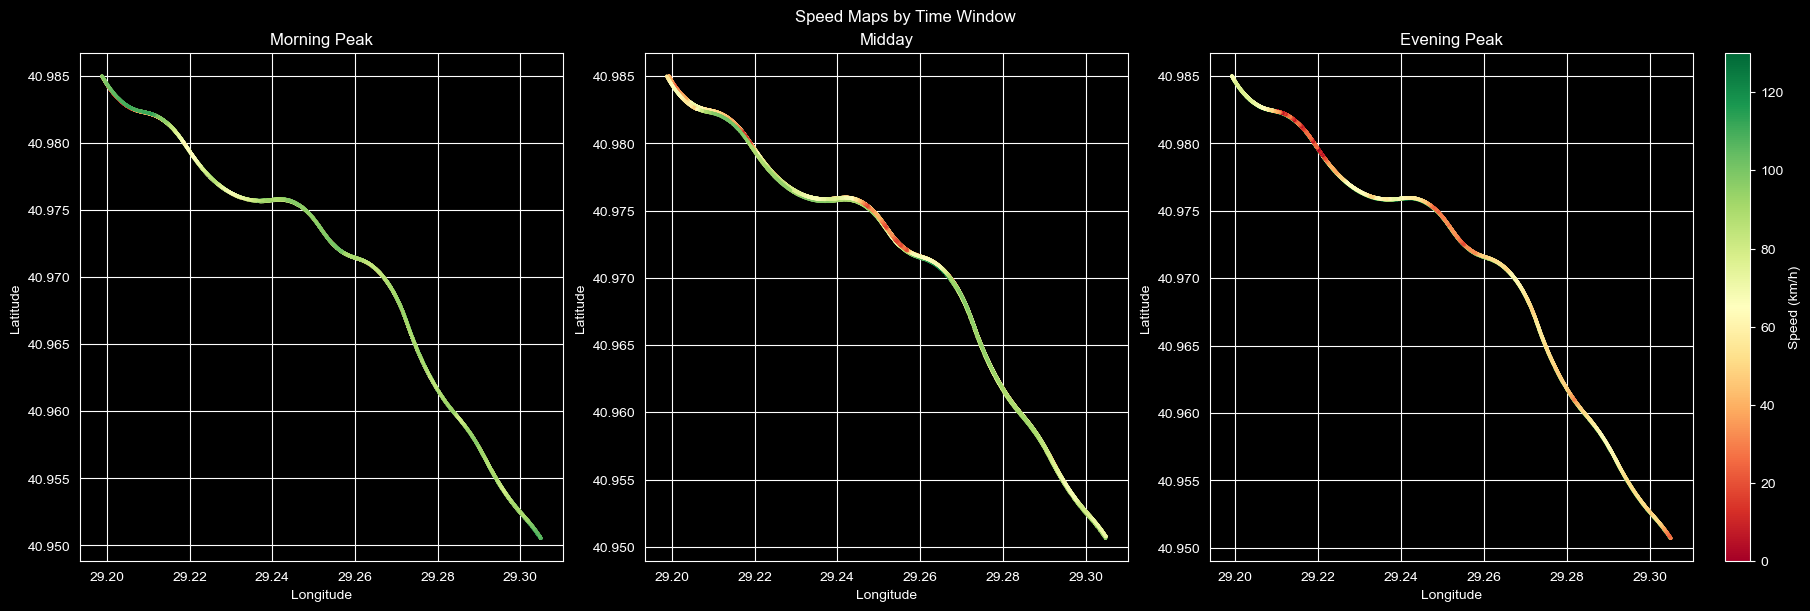

In [140]:
vmin = df_time["speed"].min()
vmax = df_time["speed"].max()

fig, axes = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=True)

windows = ["Morning Peak", "Midday", "Evening Peak"]

for ax, window in zip(axes, windows):
    subset = df_time[df_time["time_window"] == window]

    ax.scatter(
        subset["longitude"],
        subset["latitude"],
        c=subset["speed"],
        cmap="RdYlGn",
        s=2,
        vmin=vmin,
        vmax=vmax
    )

    ax.set_title(window)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

cbar = fig.colorbar(
    plt.cm.ScalarMappable(cmap="RdYlGn", norm=plt.Normalize(vmin=vmin, vmax=vmax)),
    ax=axes,
    fraction=0.02,
    pad=0.02
)

cbar.set_label("Speed (km/h)")

plt.suptitle("Speed Maps by Time Window")
plt.show()

In [141]:
from sklearn.cluster import DBSCAN
import numpy as np

# cluster points based on location
coords = df_filtered[["longitude", "latitude"]].to_numpy()

# epsilon ~ small distance (tune if needed)
clustering = DBSCAN(eps=0.002, min_samples=50).fit(coords)

df_filtered["cluster"] = clustering.labels_

# keep largest cluster only
largest_cluster = df_filtered["cluster"].value_counts().idxmax()

df_filtered = df_filtered[df_filtered["cluster"] == largest_cluster].copy()

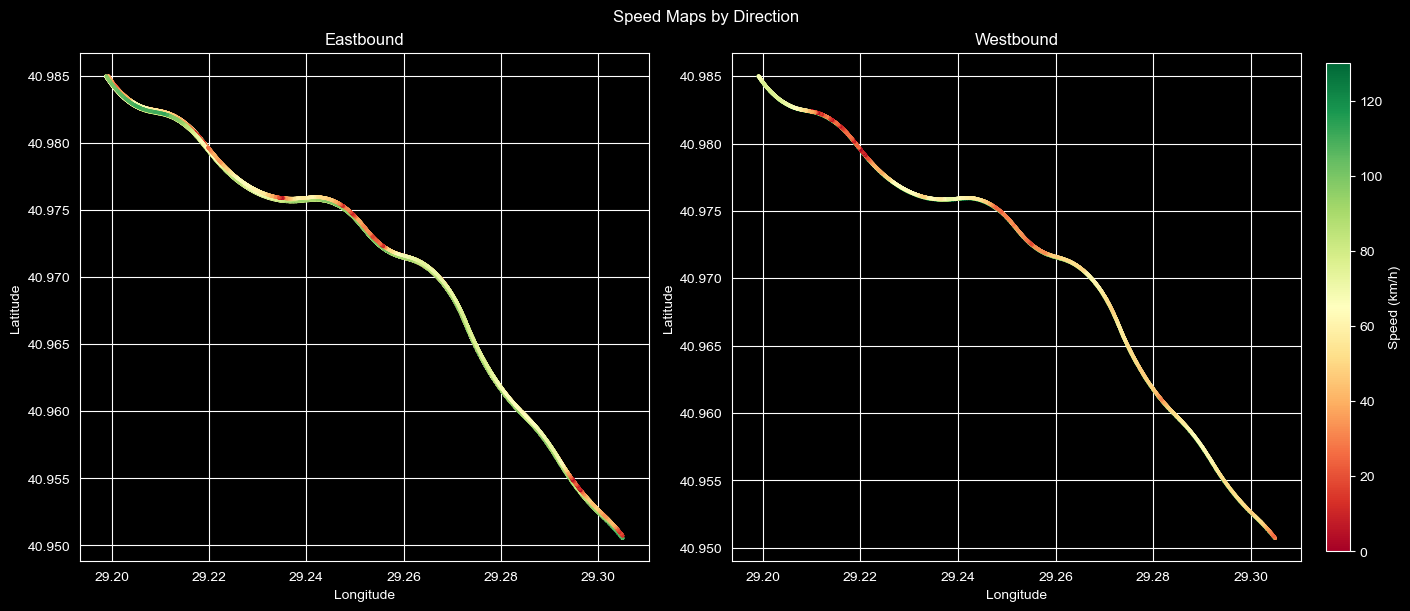

In [142]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

directions = ["Eastbound", "Westbound"]

for ax, direction in zip(axes, directions):
    subset = df_filtered[df_filtered["direction"] == direction]

    ax.scatter(
        subset["longitude"],
        subset["latitude"],
        c=subset["speed"],
        cmap="RdYlGn",
        s=2,
        vmin=vmin,
        vmax=vmax
    )

    ax.set_title(direction)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

cbar = fig.colorbar(
    plt.cm.ScalarMappable(cmap="RdYlGn", norm=plt.Normalize(vmin=vmin, vmax=vmax)),
    ax=axes,
    fraction=0.02,
    pad=0.02
)

cbar.set_label("Speed (km/h)")

plt.suptitle("Speed Maps by Direction")
plt.show()

In [143]:
import folium

m = folium.Map(
    location=[df_filtered["latitude"].mean(), df_filtered["longitude"].mean()],
    zoom_start=12
)

for _, row in df_filtered.sample(5000).iterrows():
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=2,
        color="blue",
        fill=True
    ).add_to(m)

m

In [144]:
df_time.groupby("time_window")["speed"].agg(["count", "mean", "median", "std"])

,count,mean,median,std
time_window,,,,
Evening Peak,8914,65.023671,68.0,29.495549
Midday,9710,59.170134,67.0,26.486218
Morning Peak,9142,72.826953,82.0,31.777854


In [145]:
(df_time["speed"] < 40).groupby(df_time["time_window"]).mean()

time_window
Evening Peak    0.237716
Midday          0.272606
Morning Peak    0.210457
Name: speed, dtype: float64

## Hypotheses

H1: Average vehicle speed on the selected O-4 segment differs across time windows (morning peak, midday, evening peak).

H2: The proportion of low-speed observations (speed < 40 km/h) differs across time windows.

## Findings

The exploratory analysis shows that traffic behavior on the selected O-4 segment varies across different times of day.

Morning traffic appears relatively smooth overall, with the highest average speeds and the lowest share of slow observations. Midday has the lowest average speed and the highest proportion of low-speed points, suggesting broader segment-wide slowdown. Evening traffic is also slower than morning and appears to contain more visually distinct localized slowdowns than midday in the current subset.

The spatial maps also reveal that certain parts of the segment consistently appear slower than others, regardless of time window. This suggests that the slowdowns are not random and that specific locations along the corridor are prone to recurring congestion.

At first glance, the midday result may seem counterintuitive, since evening traffic is usually expected to be worse. However, this can be explained by the fact that the selected segment does not capture the primary morning bottleneck. Instead, congestion appears to propagate along the corridor over time, becoming more visible in this segment during midday.

Overall, traffic behavior on this segment is influenced by both time of day and location. While some slowdown patterns recur at specific locations, the form and intensity of congestion vary across different periods of the day.

These findings should be interpreted as preliminary, since they are based on a representative subsection used for the EDA stage rather than the full study corridor. A more complete analysis using the full route may reveal additional patterns.